Done


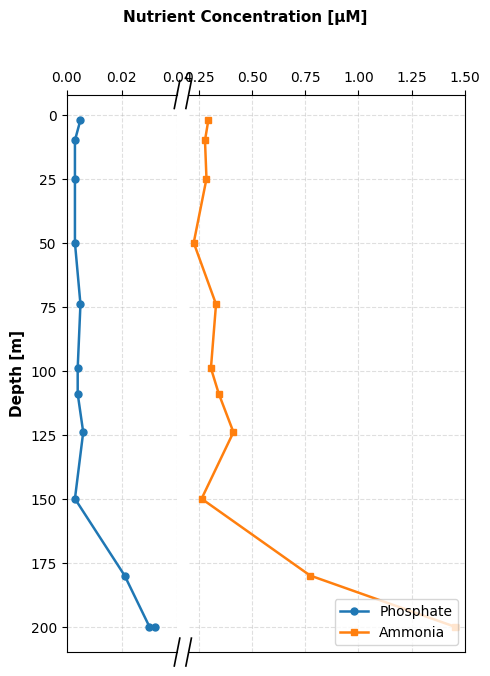

In [2]:
import io
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

csv_data = """Depth,Phosphate,Ammonia
2,0.0050,0.293
10,0.0030,0.277
25,0.0030,0.284
50,0.0030,0.224
74,0.0050,0.329
99,0.0040,0.305
109,0.0040,0.342
124,0.0060,0.411
150,0.0030,0.261
180,0.0210,0.772
200,0.0300,1.454
200,0.0320,"""

df = pd.read_csv(io.StringIO(csv_data))

# Make figure thinner: width 5, height 7
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, gridspec_kw={'width_ratios': [1, 2.5]}, figsize=(5, 7))

# Plot Phosphate & Ammonia
line1 = ax1.plot(df['Phosphate'], df['Depth'], 'o-', color='tab:blue', label='Phosphate', linewidth=1.8, markersize=5)
ax1.set_xlim(0.00, 0.04)
ax1.set_ylabel('Depth [m]', fontsize=11, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)

line2 = ax2.plot(df['Ammonia'], df['Depth'], 's-', color='tab:orange', label='Ammonia', linewidth=1.8, markersize=5)
ax2.set_xlim(0.2, 1.5)
ax2.grid(True, linestyle='--', alpha=0.4)

# Invert Y axis
ax1.invert_yaxis()

# Move X-axis ticks and labels to TOP
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')

# Hide dividing spines
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_ticks_position('none')

# Add cut marks (//)
d = 0.025  # adjust mark size for narrower plot
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.2)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)        # Bottom-right
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Top-right

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d * 0.4, +d * 0.4), (-d, +d), **kwargs)        # Bottom-left
ax2.plot((-d * 0.4, +d * 0.4), (1 - d, 1 + d), **kwargs)  # Top-left

# Overall X label on TOP
fig.supxlabel('Nutrient Concentration [µM]', fontsize=11, fontweight='bold', y=0.98)

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='lower right', frameon=True)

plt.tight_layout()
plt.subplots_adjust(wspace=0.06, top=0.88)
plt.savefig('broken_axis_top_thin.png', dpi=300, bbox_inches='tight')
print("Done")

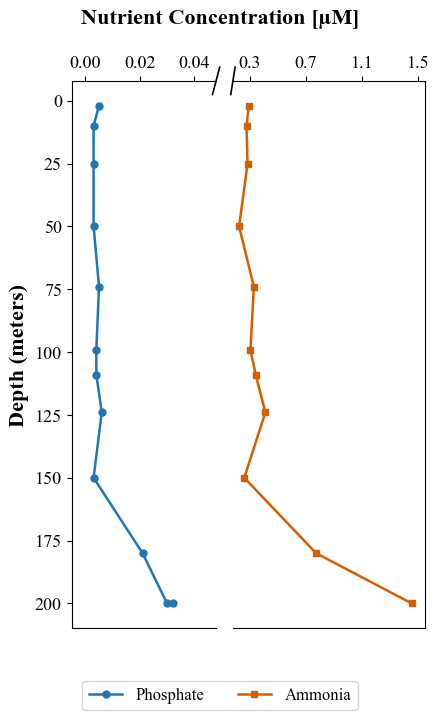

In [7]:
import io
import matplotlib.pyplot as plt
import pandas as pd

# Global font settings for Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']

csv_data = """Depth,Phosphate,Ammonia
2,0.0050,0.293
10,0.0030,0.277
25,0.0030,0.284
50,0.0030,0.224
74,0.0050,0.329
99,0.0040,0.305
109,0.0040,0.342
124,0.0060,0.411
150,0.0030,0.261
180,0.0210,0.772
200,0.0300,1.454
200,0.0320,"""

df = pd.read_csv(io.StringIO(csv_data))

# Figure dimensions and subplot ratio
fig, (ax1, ax2) = plt.subplots(
    1, 2, sharey=True, gridspec_kw={'width_ratios': [1.5, 2.0]}, figsize=(4.5, 7.5)
)

# Left Panel: Phosphate (Blue)
line1, = ax1.plot(
    df['Phosphate'], df['Depth'], 'o-', color='tab:blue', linewidth=1.8, markersize=5, label='Phosphate'
)
ax1.set_xlim(-0.005, 0.048)
ax1.set_xticks([0.00, 0.02, 0.04])

# Right Panel: Ammonia (#D55E00)
line2, = ax2.plot(
    df['Ammonia'], df['Depth'], 's-', color='#D55E00', linewidth=1.8, markersize=5, label='Ammonia'
)
ax2.set_xlim(0.18, 1.55)
ax2.set_xticks([0.3, 0.7, 1.1, 1.5])

# Invert Y-axis
ax1.invert_yaxis()

# Font sizes for axis labels and ticks
ax1.set_ylabel('Depth (meters)', fontsize=16, fontweight='bold')
ax1.tick_params(axis='both', labelsize=13)
ax2.tick_params(axis='both', labelsize=13)

# Position X-axis ticks and labels at the TOP
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')

# Hide interior vertical spines
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_ticks_position('none')

# Add axis gap / break marks
d = 0.025
kwargs_top1 = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.2)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_top1)

kwargs_top2 = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=1.2)
ax2.plot((-d * 0.45, +d * 0.45), (1 - d, 1 + d), **kwargs_top2)

# Top X-axis title centered above panels
fig.supxlabel('Nutrient Concentration [µM]', fontsize=16, fontweight='bold', y=0.9)

# External Legend centered below the plot area
fig.legend(
    handles=[line1, line2],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    # frameon=True,
    fontsize=12
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.10, top=0.83, bottom=0.10)
plt.savefig('broken_axis_legend_outside.png', dpi=300, bbox_inches='tight')
plt.show()

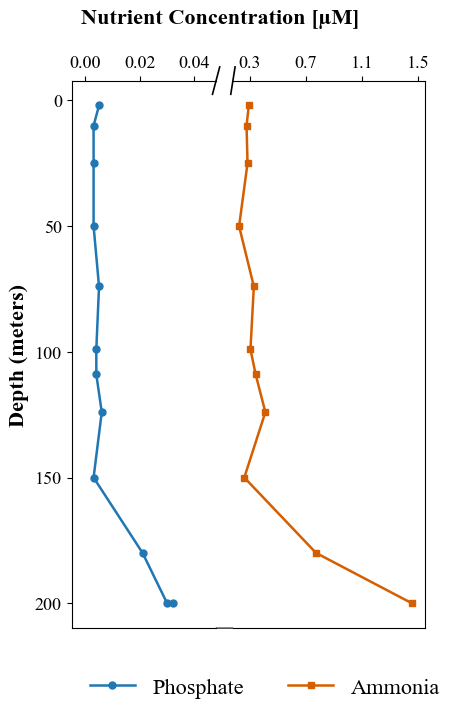

In [17]:
import io
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import ConnectionPatch

# Global font settings for Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']

csv_data = """Depth,Phosphate,Ammonia
2,0.0050,0.293
10,0.0030,0.277
25,0.0030,0.284
50,0.0030,0.224
74,0.0050,0.329
99,0.0040,0.305
109,0.0040,0.342
124,0.0060,0.411
150,0.0030,0.261
180,0.0210,0.772
200,0.0300,1.454
200,0.0320,"""

df = pd.read_csv(io.StringIO(csv_data))

# Figure dimensions and subplot ratio
fig, (ax1, ax2) = plt.subplots(
    1, 2, sharey=True, gridspec_kw={'width_ratios': [1.5, 2.0]}, figsize=(4.5, 7.5)
)

# Left Panel: Phosphate (Blue)
line1, = ax1.plot(
    df['Phosphate'], df['Depth'], 'o-', color='tab:blue', linewidth=1.8, markersize=5, label='Phosphate'
)
ax1.set_xlim(-0.005, 0.048)
ax1.set_xticks([0.00, 0.02, 0.04])

# Right Panel: Ammonia (#D55E00)
line2, = ax2.plot(
    df['Ammonia'], df['Depth'], 's-', color='#D55E00', linewidth=1.8, markersize=5, label='Ammonia'
)
ax2.set_xlim(0.18, 1.55)
ax2.set_xticks([0.3, 0.7, 1.1, 1.5])

# Explicitly set Y-axis ticks in increments of 50 (0, 50, 100, 150, 200) and invert
ax1.set_yticks(range(0, 201, 50))
ax1.invert_yaxis()

# Font sizes for axis labels and ticks
ax1.set_ylabel('Depth (meters)', fontsize=16, fontweight='bold')
ax1.tick_params(axis='both', labelsize=13)
ax2.tick_params(axis='both', labelsize=13)

# Position X-axis ticks and labels at the TOP
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')

# Hide interior vertical spines
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_ticks_position('none')

# Add axis gap / break marks on top
d = 0.025
kwargs_top1 = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.2)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_top1)

kwargs_top2 = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=1.2)
ax2.plot((-d * 0.45, +d * 0.45), (1 - d, 1 + d), **kwargs_top2)

# Connect bottom spines across the gap to form a continuous straight bottom line
bottom_line = ConnectionPatch(
    xyA=(1, 0), xyB=(0, 0),
    coordsA="axes fraction", coordsB="axes fraction",
    axesA=ax1, axesB=ax2,
    color="black", linewidth=plt.rcParams['axes.linewidth']
)
fig.add_artist(bottom_line)

# Top X-axis title centered above panels
fig.supxlabel('Nutrient Concentration [µM]', fontsize=16, fontweight='bold', y=0.9)

# External Legend centered below the plot area without border frame
fig.legend(
    handles=[line1, line2],
    loc='lower center',
    bbox_to_anchor=(0.6, -0.02),
    ncol=2,
    frameon=False,
    fontsize=16
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.10, top=0.83, bottom=0.10)
plt.savefig('broken_axis_legend_outside.png', dpi=300, bbox_inches='tight')
plt.show()